# Reccurent Neural Network on SM/MET Data

In this notebook you will find the following tasks: 

1. Data Processing: Reading in the data, cleaning it to remove null values and features, adding features for geographical location, engineering time and wind to fit our needs and combinng stations into one data frame. 
2. Batching and Train/Test Split: Defining our target station and features, creating a fuinction to split training data into batches for the general reccurent unit.
3. Model Creation + Training: Defining the model inputs, creating the sequential structure, optimizing, defining call backs, and training.
4. Model Evaluation: Nothing yet 

Goals: 

We want to train the model sequentially on every station besides our target station, and then test the target station predictions. Currently I have a shape error I'm working around regarding the input shape to the model. 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
%cd /content/drive/My Drive/TX_DATA

/content/drive/My Drive/TX_DATA


In [3]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive

#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False



# Data Cleansing, Normalization and Feature Engineering

In [4]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [5]:
# Check if dfs contains NaN values
for station, df in dfs.items() :
  print(station)
  print(df.isnull().sum())
  print()

Station1
Ppt_x            582
SWC_5            646
SWC_10           595
SWC_20           792
SWC_50           607
T_5              582
T_10             582
T_20             582
T_50             582
Flag               0
Ppt_y            583
Tair             588
RH               583
Windspeed        583
Winddirection    583
Srad             583
dtype: int64

Station2
Ppt_x            0
SWC_5            2
SWC_10           1
SWC_20           1
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station3
Ppt_x             0
SWC_5             0
SWC_10            0
SWC_20            0
SWC_50            0
T_5               0
T_10              0
T_20              0
T_50              0
Flag              0
Ppt_y             0
Tair              0
RH                0
Windspeed         0
Winddirection     0
Srad 

In [6]:
for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [7]:
for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  print(station)
  print(df_new.describe().transpose())
  dfs[station] = df_new
  print()

Station1
                 count        mean         std      min      25%      50%  \
Ppt_soil       57611.0    0.068267    0.850934    0.000    0.000    0.000   
SWC_5          57611.0    0.142948    0.052155    0.043    0.098    0.137   
SWC_10         57611.0    0.156585    0.040307    0.084    0.122    0.155   
SWC_20         57611.0    0.138416    0.033174    0.086    0.106    0.139   
T_5            57611.0   22.890574    9.520338    0.760   15.465   22.890   
T_10           57611.0   22.899939    8.911716    1.780   15.710   23.030   
T_20           57611.0   22.836532    8.428353    2.760   15.850   22.990   
Ppt_met        57611.0    0.068307    0.850937    0.000    0.000    0.000   
Tair           57611.0   14.861630   22.042080 -173.200   12.030   19.480   
RH             57611.0   64.902492   28.541111  -96.300   48.105   70.100   
Windspeed      57611.0    1.842692    1.166921    0.000    0.948    1.831   
Winddirection  57611.0  160.446910   84.544296    0.000  104.900  1

Text(0, 0.5, 'Wind Velocity [m/s]')

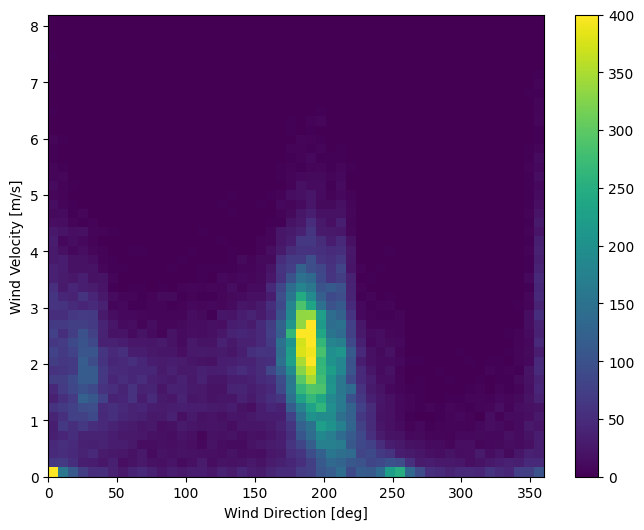

In [8]:
# distribution of wind data (station 1 for example)
plt.hist2d(dfs['Station1']['Winddirection'], dfs['Station1']['Windspeed'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

In [9]:
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

(-7.808186098707588, 8.1975522162057, -4.273160359540029, 4.754479689602174)

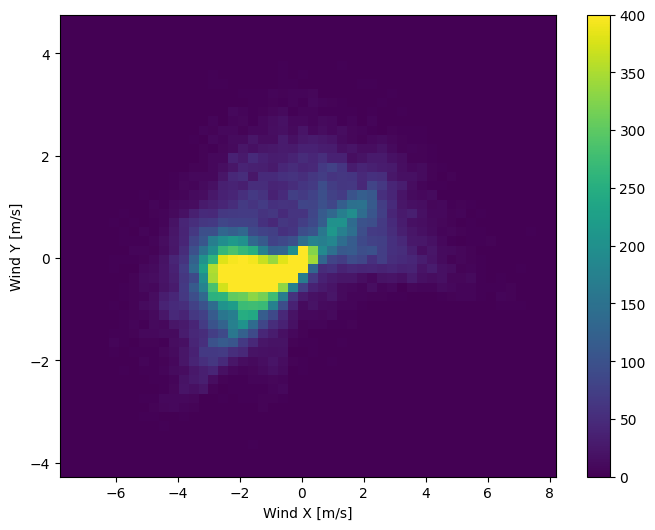

In [10]:
# The distribution of wind vectors is much simpler for the model to correctly interpret (station 1 for example)
plt.hist2d(dfs['Station1']['Wx'], dfs['Station1']['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [11]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

Text(0.5, 1.0, 'Time of day signal')

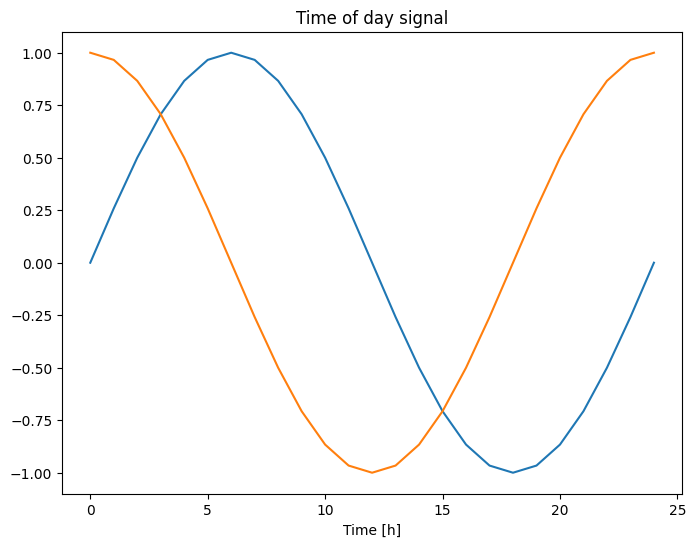

In [12]:
# plot day sin and cos (station 1 for example)
plt.plot(np.array(dfs['Station1']['Day sin'])[:25])
plt.plot(np.array(dfs['Station1']['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [13]:
#Normalize all the data

for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [14]:
position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [15]:
dfs['Station2']

,Ppt_soil,SWC_5,SWC_10,SWC_20,T_5,T_10,T_20,Ppt_met,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos,Latitude,Longitude
Date,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.000000,0.423237,0.355856,0.419087,0.075590,0.090119,0.115674,0.000000,0.286070,0.842701,0.000000,0.666014,0.600224,0.500000,1.000000,0.500753,0.999999,30.4193,-98.8046
2015-01-01 01:00:00,0.000000,0.423237,0.355856,0.419087,0.073424,0.087140,0.113071,0.000000,0.288257,0.810640,0.000037,0.655949,0.600384,0.629410,0.982963,0.501111,0.999999,30.4193,-98.8046
2015-01-01 02:00:00,0.000000,0.423237,0.355856,0.419087,0.072558,0.085154,0.110758,0.000000,0.292312,0.803627,0.000230,0.664114,0.606422,0.750000,0.933013,0.501469,0.999998,30.4193,-98.8046
2015-01-01 03:00:00,0.000000,0.423237,0.355856,0.419087,0.071692,0.083913,0.108155,0.000000,0.295357,0.790001,0.000147,0.658961,0.643275,0.853553,0.853553,0.501828,0.999997,30.4193,-98.8046
2015-01-01 04:00:00,0.009561,0.423237,0.355856,0.419087,0.070609,0.082423,0.106709,0.009524,0.295104,0.900812,0.000000,0.632092,0.579426,0.933013,0.750000,0.502186,0.999995,30.4193,-98.8046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.000000,0.813278,0.810811,0.763485,0.453325,0.498759,0.550896,0.000000,0.676649,0.890793,0.132320,0.423312,0.491195,0.853553,0.146447,0.713254,0.047758,30.4193,-98.8046
2021-06-06 10:00:00,0.000000,0.813278,0.810811,0.759336,0.455491,0.499752,0.550607,0.000000,0.705754,0.752229,0.506814,0.376989,0.462637,0.750000,0.066987,0.712929,0.047605,30.4193,-98.8046
2021-06-06 11:00:00,0.000000,0.809129,0.806306,0.759336,0.462855,0.502979,0.550896,0.000000,0.745794,0.715660,0.744936,0.384336,0.515880,0.629410,0.017037,0.712605,0.047453,30.4193,-98.8046


In [16]:
for station, df in dfs.items():
  print(len(df))

57611
56364
58365
58307
47804
58341


In [17]:
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [18]:
#only use data shared all together

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


In [19]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [20]:
index = index_int 

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [21]:
data = pd.DataFrame(index = index_int)

for station, df in dfs.items():
  for col in df.columns:
    data[f"{station} {col}"] = df[col][index_int]

data = data.values

<ipython-input-21-b0794346bdbc>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{station} {col}"] = df[col][index_int]
<ipython-input-21-b0794346bdbc>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{station} {col}"] = df[col][index_int]
<ipython-input-21-b0794346bdbc>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

In [22]:
data

array([[  0.13962264,   0.21962617,   0.20805369, ...,  30.2758    ,
        -98.7242    ,   0.        ],
       [  0.14339623,   0.22429907,   0.20805369, ...,  30.2758    ,
        -98.7242    ,   0.        ],
       [  0.14716981,   0.22897196,   0.2147651 , ...,  30.2758    ,
        -98.7242    ,   0.        ],
       ...,
       [  0.75849057,   0.54672897,   0.7114094 , ...,  30.2758    ,
        -98.7242    ,   0.        ],
       [  0.75471698,   0.54672897,   0.7114094 , ...,  30.2758    ,
        -98.7242    ,   0.        ],
       [  0.74716981,   0.54672897,   0.7114094 , ...,  30.2758    ,
        -98.7242    ,   0.        ]])

In [23]:
df = pd.DataFrame(data = data, index = index, columns = cols)

In [24]:
df

Station              Station1                                          \
Feature                 SWC_5    SWC_10    SWC_20       T_5      T_10   
2016-02-20 13:00:00  0.139623  0.219626  0.208054  0.409553  0.414440   
2016-02-20 15:00:00  0.143396  0.224299  0.208054  0.451220  0.447961   
2016-02-20 16:00:00  0.147170  0.228972  0.214765  0.463618  0.462260   
2016-02-20 17:00:00  0.143396  0.228972  0.208054  0.468089  0.472808   
2016-02-20 18:00:00  0.143396  0.228972  0.214765  0.457317  0.476090   
...                       ...       ...       ...       ...       ...   
2021-06-06 09:00:00  0.758491  0.551402  0.718121  0.455285  0.498594   
2021-06-06 10:00:00  0.758491  0.546729  0.711409  0.468496  0.505860   
2021-06-06 11:00:00  0.758491  0.546729  0.711409  0.498984  0.518987   
2021-06-06 12:00:00  0.754717  0.546729  0.711409  0.554472  0.550398   
2021-06-06 13:00:00  0.747170  0.546729  0.711409  0.601829  0.588608   

Station                                                                ...  \
Feature                  T_20      Tair        RH      Srad        Wx  ...   
2016-02-20 13:00:00  0.417014  0.912188  0.870606  0.350557  0.318500  ...   
2016-02-20 15:00:00  0.434964  0.917929  0.812634  0.367328  0.353486  ...   
2016-02-20 16:00:00  0.445890  0.924424  0.799389  0.392486  0.368937  ...   
2016-02-20 17:00:00  0.456296  0.927341  0.797453  0.213525  0.369872  ...   
2016-02-20 18:00:00  0.465140  0.924894  0.823484  0.078887  0.390298  ...   
...                       ...       ...       ...       ...       ...  ...   
2021-06-06 09:00:00  0.533559  0.920141  0.941416  0.180612  0.335740  ...   
2021-06-06 10:00:00  0.534860  0.924188  0.906775  0.308349  0.347136  ...   
2021-06-06 11:00:00  0.539282  0.935012  0.863627  0.737477  0.315928  ...   
2021-06-06 12:00:00  0.549688  0.942259  0.838767  0.885900  0.310358  ...   
2021-06-06 13:00:00  0.569199  0.946776  0.833316  0.927644  0.299121  ...   

Station              Station6                                          \
Feature                  Srad        Wx        Wy   Day sin   Day cos   
2016-02-20 13:00:00  0.326054  0.327554  0.519249  0.370590  0.017037   
2016-02-20 15:00:00  0.380189  0.385141  0.561426  0.146447  0.146447   
2016-02-20 16:00:00  0.443144  0.382056  0.563651  0.066987  0.250000   
2016-02-20 17:00:00  0.196865  0.413326  0.599024  0.017037  0.370590   
2016-02-20 18:00:00  0.076036  0.429337  0.603361  0.000000  0.500000   
...                       ...       ...       ...       ...       ...   
2021-06-06 09:00:00  0.152973  0.409350  0.608478  0.853553  0.146447   
2021-06-06 10:00:00  0.430991  0.449031  0.668760  0.750000  0.066987   
2021-06-06 11:00:00  0.777477  0.375301  0.659724  0.629410  0.017037   
2021-06-06 12:00:00  0.873874  0.372571  0.608229  0.500000  0.000000   
2021-06-06 13:00:00  0.881982  0.353124  0.652895  0.370590  0.017037   

Station                                                          
Feature              Year sin  Year cos Latitude Longitude  PPT  
2016-02-20 13:00:00  0.881128  0.823638  30.2758  -98.7242  0.0  
2016-02-20 15:00:00  0.881591  0.823091  30.2758  -98.7242  0.0  
2016-02-20 16:00:00  0.881823  0.822818  30.2758  -98.7242  0.0  
2016-02-20 17:00:00  0.882054  0.822544  30.2758  -98.7242  0.0  
2016-02-20 18:00:00  0.882285  0.822270  30.2758  -98.7242  0.0  
...                       ...       ...      ...       ...  ...  
2021-06-06 09:00:00  0.713254  0.047758  30.2758  -98.7242  0.0  
2021-06-06 10:00:00  0.712929  0.047605  30.2758  -98.7242  0.0  
2021-06-06 11:00:00  0.712605  0.047453  30.2758  -98.7242  0.0  
2021-06-06 12:00:00  0.712281  0.047300  30.2758  -98.7242  0.0  
2021-06-06 13:00:00  0.711956  0.047148  30.2758  -98.7242  0.0  

[45185 rows x 108 columns]

# Data Split

In [25]:
target_station = 'Station6'

target_names = ['SWC_5']

shift_days = 1

shift_steps = shift_days*24

target_df = df[target_station][target_names]

target_df = target_df.shift(-shift_steps)

target_df = target_df.drop(index=target_df.index[-shift_steps:])

target_df.shape

(45161, 1)

In [26]:
non_targets = list(dfs.keys())
non_targets.remove('Station6')

train_df = df[non_targets]
train_df = train_df.shift(-shift_steps)
train_df = train_df.drop(index=target_df.index[-shift_steps:])
train_df

Station              Station1                                          \
Feature                 SWC_5    SWC_10    SWC_20       T_5      T_10   
2016-02-20 13:00:00  0.143396  0.219626  0.201342  0.398780  0.419597   
2016-02-20 15:00:00  0.143396  0.219626  0.201342  0.409959  0.427098   
2016-02-20 16:00:00  0.143396  0.224299  0.201342  0.421138  0.436240   
2016-02-20 17:00:00  0.143396  0.224299  0.201342  0.414431  0.440459   
2016-02-20 18:00:00  0.143396  0.224299  0.201342  0.406911  0.438819   
...                       ...       ...       ...       ...       ...   
2021-06-06 09:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 10:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 11:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 12:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 13:00:00       NaN       NaN       NaN       NaN       NaN   

Station                                                                ...  \
Feature                  T_20      Tair        RH      Srad        Wx  ...   
2016-02-20 13:00:00  0.428980  0.915671  0.887672  0.158284  0.529628  ...   
2016-02-20 15:00:00  0.432882  0.915388  0.879572  0.263803  0.487454  ...   
2016-02-20 16:00:00  0.437825  0.914118  0.892664  0.116067  0.436709  ...   
2016-02-20 17:00:00  0.443288  0.911812  0.891136  0.062338  0.438402  ...   
2016-02-20 18:00:00  0.446150  0.908988  0.930718  0.026865  0.513057  ...   
...                       ...       ...       ...       ...       ...  ...   
2021-06-06 09:00:00       NaN       NaN       NaN       NaN       NaN  ...   
2021-06-06 10:00:00       NaN       NaN       NaN       NaN       NaN  ...   
2021-06-06 11:00:00       NaN       NaN       NaN       NaN       NaN  ...   
2021-06-06 12:00:00       NaN       NaN       NaN       NaN       NaN  ...   
2021-06-06 13:00:00       NaN       NaN       NaN       NaN       NaN  ...   

Station              Station5                                          \
Feature                  Srad        Wx        Wy   Day sin   Day cos   
2016-02-20 13:00:00  0.133345  0.468238  0.683006  0.250000  0.066987   
2016-02-20 15:00:00  0.278966  0.468501  0.744706  0.146447  0.146447   
2016-02-20 16:00:00  0.163844  0.446784  0.688307  0.066987  0.250000   
2016-02-20 17:00:00  0.051233  0.500769  0.635638  0.017037  0.370590   
2016-02-20 18:00:00  0.030145  0.606376  0.646499  0.000000  0.500000   
...                       ...       ...       ...       ...       ...   
2021-06-06 09:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 10:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 11:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 12:00:00       NaN       NaN       NaN       NaN       NaN   
2021-06-06 13:00:00       NaN       NaN       NaN       NaN       NaN   

Station                                                          
Feature              Year sin  Year cos Latitude Longitude  PPT  
2016-02-20 13:00:00  0.886866  0.816757  30.2454  -98.7059  0.0  
2016-02-20 15:00:00  0.887093  0.816480  30.2454  -98.7059  0.0  
2016-02-20 16:00:00  0.887319  0.816202  30.2454  -98.7059  0.0  
2016-02-20 17:00:00  0.887546  0.815924  30.2454  -98.7059  0.0  
2016-02-20 18:00:00  0.887772  0.815646  30.2454  -98.7059  0.0  
...                       ...       ...      ...       ...  ...  
2021-06-06 09:00:00       NaN       NaN      NaN       NaN  NaN  
2021-06-06 10:00:00       NaN       NaN      NaN       NaN  NaN  
2021-06-06 11:00:00       NaN       NaN      NaN       NaN  NaN  
2021-06-06 12:00:00       NaN       NaN      NaN       NaN  NaN  
2021-06-06 13:00:00       NaN       NaN      NaN       NaN  NaN  

[45161 rows x 90 columns]

In [27]:
num_data = len(train_df)
train_split = 0.9
num_train = int(train_split * num_data)
num_test = num_data - num_train

num_x_signals = train_df["Station1"].values.shape[1]
num_y_signals = target_df.values.shape[1]

print(num_x_signals)
print(num_y_signals)

18
1


In [28]:
#Train Test Split

x_data = train_df["Station1"].values
y_data = target_df.values

x_train = x_data[0:num_train]
x_test = x_data[num_train:]

y_train = y_data[0:num_train]
y_test = y_data[num_train:]

In [29]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(40644, 18)
(40644, 1)
(4517, 18)
(4517, 1)


# Data Generation

In [30]:
def batch_generator(batch_size, sequence_length, x_train, y_train):
    """
    Generator function for creating random batches of training-data.
    """

    # Infinite loop.
    while True:
        # Allocate a new array for the batch of input-signals.
        x_shape = (batch_size, sequence_length, num_x_signals)
        x_batch = np.zeros(shape=x_shape, dtype=np.float16)

        # Allocate a new array for the batch of output-signals.
        y_shape = (batch_size, sequence_length, num_y_signals)
        y_batch = np.zeros(shape=y_shape, dtype=np.float16)

        # Fill the batch with random sequences of data.
        for i in range(batch_size):
            # Get a random start-index.
            # This points somewhere into the training-data.
            idx = np.random.randint(num_train - sequence_length)
            
            # Copy the sequences of data starting at this index.
            x_batch[i] = x_train[idx:idx+sequence_length]
            y_batch[i] = y_train[idx:idx+sequence_length]
        
        yield (x_batch, y_batch)

In [31]:
batch_size = 64
sequence_length = 24 * 7 * 8
sequence_length

1344

In [32]:
generator = batch_generator(batch_size=batch_size,
                            sequence_length=sequence_length, x_train = x_train, y_train = y_train)

In [33]:
x_batch, y_batch = next(generator)

In [34]:
print(x_batch.shape)
print(y_batch.shape)

(64, 1344, 18)
(64, 1344, 1)


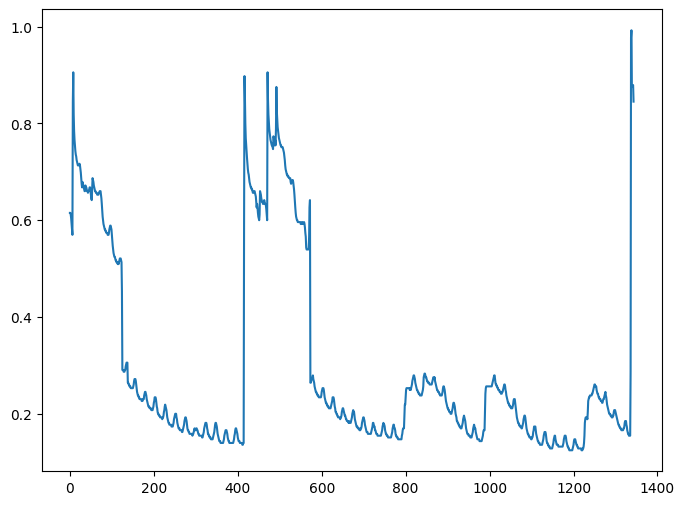

In [35]:
batch = 0   # First sequence in the batch.
signal = 0  # First signal from the 20 input-signals.
seq = x_batch[batch, :, signal]
plt.plot(seq)

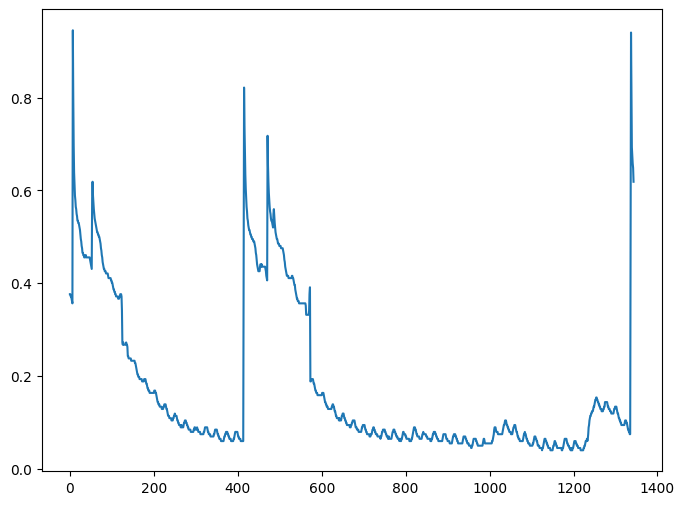

In [36]:
seq = y_batch[batch, :, signal]
plt.plot(seq)


In [37]:
validation_data = (np.expand_dims(x_test, axis=0),
                   np.expand_dims(y_test, axis=0))

validation_data[0].shape

(1, 4517, 18)

# Making and Training RNN Model

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, GRU, Embedding
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.backend import square, mean

In [39]:
#make a function soon

model = Sequential()

model.add(GRU(units=512,
              return_sequences=True,
              input_shape=(None, num_x_signals,)))
model.add(Dense(num_y_signals, activation='sigmoid'))

if False:
    from tensorflow.python.keras.initializers import RandomUniform

    # Maybe use lower init-ranges.
    init = RandomUniform(minval=-0.05, maxval=0.05)

    model.add(Dense(num_y_signals,
                    activation='linear',
                    kernel_initializer=init))

In [40]:
# Custom Loss Function

In [41]:
warmup_steps = 50

In [42]:
def loss_mse_warmup(y_true, y_pred):
    """
    Calculate the Mean Squared Error between y_true and y_pred,
    but ignore the beginning "warmup" part of the sequences.
    
    y_true is the desired output.
    y_pred is the model's output.
    """

    # The shape of both input tensors are:
    # [batch_size, sequence_length, num_y_signals].

    # Ignore the "warmup" parts of the sequences
    # by taking slices of the tensors.
    y_true_slice = y_true[:, warmup_steps:, :]
    y_pred_slice = y_pred[:, warmup_steps:, :]

    # These sliced tensors both have this shape:
    # [batch_size, sequence_length - warmup_steps, num_y_signals]

    # Calculat the Mean Squared Error and use it as loss.
    mse = mean(square(y_true_slice - y_pred_slice))
    
    return mse

In [43]:
# Compile/Optimize 

In [44]:
optimizer = RMSprop(learning_rate=1e-3)

model.compile(loss=loss_mse_warmup, optimizer=optimizer)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, None, 512)         817152    
                                                                 
 dense (Dense)               (None, None, 1)           513       
                                                                 
Total params: 817,665
Trainable params: 817,665
Non-trainable params: 0
_________________________________________________________________


In [45]:
# Callback Functions

In [46]:
path_checkpoint = '23_checkpoint.keras'
callback_checkpoint = ModelCheckpoint(filepath=path_checkpoint,
                                      monitor='val_loss',
                                      verbose=1,
                                      save_weights_only=True,
                                      save_best_only=True)

In [47]:
callback_early_stopping = EarlyStopping(monitor='val_loss',
                                        patience=5, verbose=1)

In [48]:
callback_tensorboard = TensorBoard(log_dir='./23_logs/',
                                   histogram_freq=0,
                                   write_graph=False)

In [49]:

callback_reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                       factor=0.1,
                                       min_lr=1e-4,
                                       patience=0,
                                       verbose=1)

In [50]:
callbacks = [callback_early_stopping,
             callback_checkpoint,
             callback_tensorboard,
             callback_reduce_lr]

In [51]:
# Training 

In [52]:
%%time
model.fit(x=generator,
          epochs=1,
          steps_per_epoch=5,
          validation_data=validation_data,
          callbacks=callbacks)

5/5 [==============================] - ETA: 0s - loss: 0.1694 
Epoch 1: val_loss did not improve from inf

Epoch 1: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
5/5 [==============================] - 91s 18s/step - loss: 0.1694 - val_loss: nan - lr: 0.0010
CPU times: user 2min 7s, sys: 6.44 s, total: 2min 13s
Wall time: 1min 30s


In [55]:
# Checkpoint loading

try:
    model.load_weights(path_checkpoint)
except Exception as error:
    print("Error trying to load checkpoint.")
    print(error)

Error trying to load checkpoint.
Cannot assign value to variable ' gru/gru_cell/kernel:0': Shape mismatch.The variable shape (18, 1536), and the assigned value shape (96, 1536) are incompatible.


# Model Evaluation

In [56]:
result = model.evaluate(x=np.expand_dims(x_test, axis=0),
                        y=np.expand_dims(y_test, axis=0))

# If you have several metrics you can use this instead.
if False:
    for res, metric in zip(result, model.metrics_names):
        print("{0}: {1:.3e}".format(metric, res))

1/1 [==============================] - 1s 1s/step - loss: nan
